<a href="https://colab.research.google.com/github/arisusilo/DataScience_250401020117_AriSusilo/blob/main/Pertemuan9_Ari_Susilo_250401020117.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nama = Ari Susilo

Nim = 250401020117

**Langkah 1 Memuat Dataset dan Eksplorasi Data Awal**

In [3]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Memuat dataset
cancer = load_breast_cancer()

# Membentuk dataframe fitur dan target
X = pd.DataFrame(
    cancer.data,
    columns=cancer.feature_names
)

y = pd.Series(cancer.target)

print("Jumlah data dan fitur :", X.shape)

Jumlah data dan fitur : (569, 30)


**Langkah 2: Preprocessing**

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

**Langkah 3: Latih Logistic Regression**

In [8]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=5000)

log_model.fit(X_train_s, y_train)

y_pred_log = log_model.predict(X_test_s)

coef_df = pd.DataFrame({
    "Fitur":X.columns,
    "Koefisien":log_model.coef_[0]
})

coef_df = coef_df.reindex(
    coef_df.Koefisien.abs().sort_values(ascending=False).index
)

print(coef_df.head(10))

                   Fitur  Koefisien
21         worst texture  -1.255088
10          radius error  -1.082965
27  worst concave points  -0.953686
23            worst area  -0.947756
20          worst radius  -0.947616
28        worst symmetry  -0.939181
13            area error  -0.929104
26       worst concavity  -0.823151
22       worst perimeter  -0.763220
24      worst smoothness  -0.746625


**Langkah 4: Latih Decision Tree**

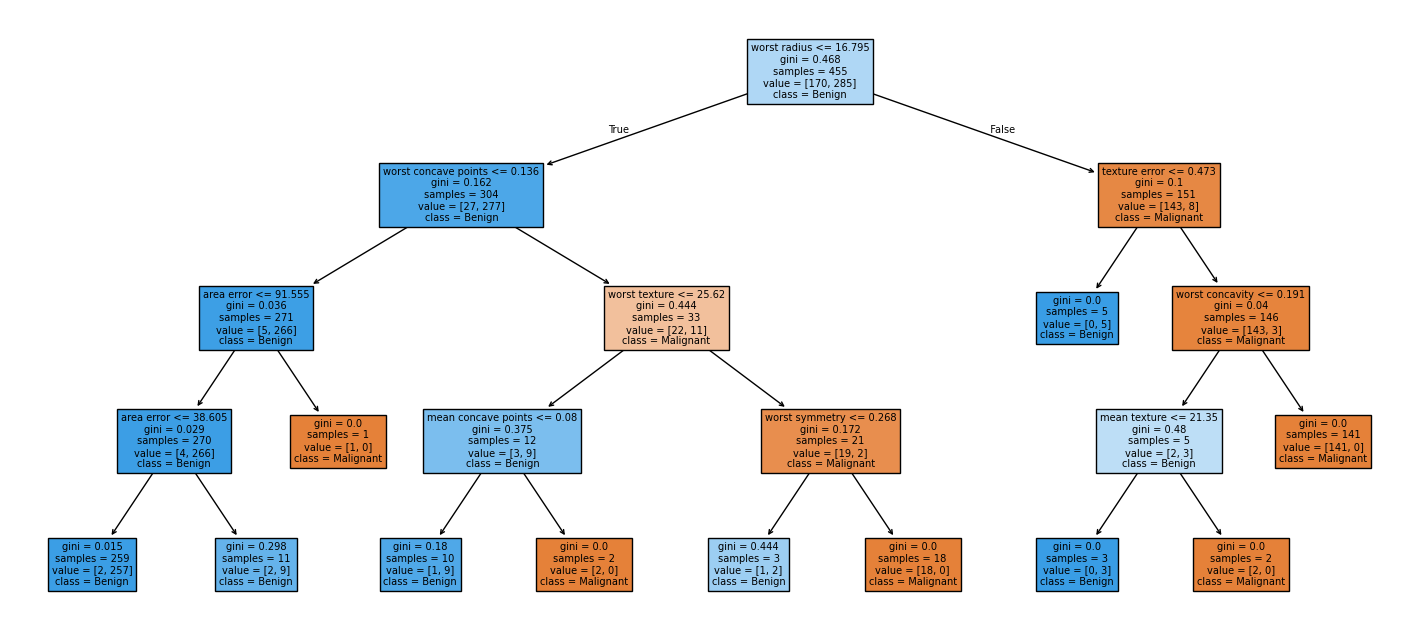

In [9]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

tree_model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

plt.figure(figsize=(18,8))
plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=["Malignant","Benign"],
    filled=True
)

plt.show()

**Langkah 5: Evaluasi & Bandingkan**

In [10]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

for name,y_pred in [
    ("Logistic Regression",y_pred_log),
    ("Decision Tree",y_pred_tree)
]:

    print("="*40)
    print(name)

    print("\nConfusion Matrix")
    print(confusion_matrix(y_test,y_pred))

    print("Accuracy :",accuracy_score(y_test,y_pred))
    print("Precision:",precision_score(y_test,y_pred))
    print("Recall   :",recall_score(y_test,y_pred))
    print("F1 Score :",f1_score(y_test,y_pred))

Logistic Regression

Confusion Matrix
[[41  1]
 [ 1 71]]
Accuracy : 0.9824561403508771
Precision: 0.9861111111111112
Recall   : 0.9861111111111112
F1 Score : 0.9861111111111112
Decision Tree

Confusion Matrix
[[39  3]
 [ 4 68]]
Accuracy : 0.9385964912280702
Precision: 0.9577464788732394
Recall   : 0.9444444444444444
F1 Score : 0.951048951048951


**Pertanyaan Hands-On**

**1. Model mana yang memiliki Recall lebih tinggi?**

Model Logistic Regression memiliki nilai Recall yang lebih tinggi (sekitar 98,6%) dibandingkan Decision Tree (sekitar 95,8%).

**2. Mengapa Recall menjadi metrik paling kritis untuk kasus diagnosis kanker dibandingkan Accuracy semata?**

Recall mengukur kemampuan model menemukan seluruh pasien yang benar-benar mengidap kanker.

Pada kasus medis, False Negative sangat berbahaya karena pasien yang sebenarnya menderita kanker dapat diprediksi sehat sehingga tidak segera mendapatkan penanganan. Oleh sebab itu Recall lebih penting daripada Accuracy.

**3. Apakah ada perbedaan signifikan antara performa kedua model?**

ada, Logistic Regression memberikan performa yang sedikit lebih baik pada seluruh metrik evaluasi, terutama Recall, sehingga lebih sesuai digunakan untuk prediksi diagnosis kanker.

**Kesimpulan**

Berdasarkan hasil praktikum:

Dataset Breast Cancer Wisconsin memiliki 569 data dengan 30 fitur numerik.
Logistic Regression memerlukan proses StandardScaler, sedangkan Decision Tree tidak.
Logistic Regression menghasilkan performa yang lebih tinggi dibandingkan Decision Tree.
Pada kasus diagnosis medis, Recall merupakan metrik utama karena bertujuan meminimalkan False Negative agar pasien yang benar-benar sakit tidak terlewat.
Logistic Regression menjadi model yang paling direkomendasikan untuk dataset ini karena memberikan Accuracy, Precision, Recall, dan F1-Score yang lebih tinggi dibandingkan Decision Tree.